<a href="https://colab.research.google.com/github/KESSSSSivasankar/Design/blob/master/Fine_Tune_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning with Performance Visualization in Google Colab

This notebook demonstrates:
- Loading a transformer model (free GPU in Colab)
- Fine-tuning via system prompt customization
- Comprehensive testing and evaluation
- Beautiful matplotlib visualizations
- Interactive Plotly dashboards
- Production readiness assessment

**Perfect for**: Learning, experimentation, and performance analysis

## Step 1: Install Dependencies

In [ ]:
!pip install transformers torch matplotlib seaborn pandas numpy plotly -q

## Step 2: Setup and Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from dataclasses import dataclass
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

# Check GPU
print("\n" + "="*70)
print("GOOGLE COLAB SETUP")
print("="*70)
print(f"✓ GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Setup plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("\n✓ All imports successful!")


GOOGLE COLAB SETUP
✓ GPU Available: False

✓ All imports successful!


## Step 3: Define Data Structures

In [3]:
@dataclass
class TrainingExample:
    """Training data structure"""
    instruction: str
    input_text: str
    expected_output: str

@dataclass
class TestResult:
    """Test result structure"""
    test_name: str
    relevance: float
    clarity: float
    helpfulness: float
    tone: float
    latency_ms: float
    overall_score: float
    passed: bool

print("✓ Data structures defined")

✓ Data structures defined


## Step 4: Create Training Data

In [4]:
def create_training_dataset() -> List[TrainingExample]:
    """Create sample training data"""
    return [
        TrainingExample(
            instruction="Answer billing question",
            input_text="Why was I charged twice this month?",
            expected_output="I apologize for the duplicate charge. Please provide your order number and we'll investigate immediately."
        ),
        TrainingExample(
            instruction="Answer refund question",
            input_text="Can I get a refund?",
            expected_output="Refunds are available within 30 days. Please provide your order number for processing."
        ),
        TrainingExample(
            instruction="Answer technical issue",
            input_text="The app keeps crashing",
            expected_output="Try clearing app cache, uninstalling and reinstalling, or updating to the latest version."
        ),
        TrainingExample(
            instruction="Answer password question",
            input_text="I forgot my password",
            expected_output="Click 'Forgot Password' on the login page and follow the reset link sent to your email."
        ),
        TrainingExample(
            instruction="Answer subscription question",
            input_text="How do I cancel my subscription?",
            expected_output="Log into your account > Settings > Subscription > Cancel. You'll retain access until billing period ends."
        ),
    ]

# Create dataset
training_data = create_training_dataset()
print(f"\n✓ Created {len(training_data)} training examples")

# Display examples
for i, example in enumerate(training_data, 1):
    print(f"\nExample {i}: {example.instruction}")
    print(f"  Input: {example.input_text}")
    print(f"  Output: {example.expected_output[:50]}...")


✓ Created 5 training examples

Example 1: Answer billing question
  Input: Why was I charged twice this month?
  Output: I apologize for the duplicate charge. Please provi...

Example 2: Answer refund question
  Input: Can I get a refund?
  Output: Refunds are available within 30 days. Please provi...

Example 3: Answer technical issue
  Input: The app keeps crashing
  Output: Try clearing app cache, uninstalling and reinstall...

Example 4: Answer password question
  Input: I forgot my password
  Output: Click 'Forgot Password' on the login page and foll...

Example 5: Answer subscription question
  Input: How do I cancel my subscription?
  Output: Log into your account > Settings > Subscription > ...


## Step 5: Load Transformer Model

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TextGenerationPipeline

print("📥 Loading model (first time may take a minute)...")

model_name = "gpt2"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,
    device_map=device
)

# Create pipeline
pipeline = TextGenerationPipeline(
    model=model,
    tokenizer=tokenizer,
    device=0 if device == "cuda" else -1
)

print(f"✓ Model loaded successfully")
print(f"✓ Using device: {device}")
print(f"✓ Model: {model_name}")

📥 Loading model (first time may take a minute)...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Model loaded successfully
✓ Using device: cpu
✓ Model: gpt2


## Step 6: Fine-Tune with System Prompt

In [7]:
# Create system prompt (fine-tuning)
system_prompt = """You are a professional customer support assistant.

GUIDELINES:
1. Be polite and empathetic
2. Provide clear solutions with steps
3. Use simple, friendly language
4. Organize information clearly
5. Offer to help further if needed

TASK: Answer customer support questions helpfully."""

print("🎯 Fine-Tuning Configuration")
print("="*70)
print(system_prompt)
print("\n✓ System prompt applied (fine-tuning via customization)")

🎯 Fine-Tuning Configuration
You are a professional customer support assistant.

GUIDELINES:
1. Be polite and empathetic
2. Provide clear solutions with steps
3. Use simple, friendly language
4. Organize information clearly
5. Offer to help further if needed

TASK: Answer customer support questions helpfully.

✓ System prompt applied (fine-tuning via customization)


## Step 7: Run Tests and Collect Metrics

In [8]:
def prepare_inference_prompt(instruction: str, input_text: str) -> str:
    return f"""{system_prompt}

Instruction: {instruction}
Input: {input_text}
Output:"""

def evaluate_response(response: str) -> Dict:
    """Evaluate response quality"""
    scores = {}

    response_len = len(response)
    scores["relevance"] = min(10, response_len / 50)

    clarity_keywords = ["please", "step", "click", "contact", "try"]
    clarity_count = sum(1 for kw in clarity_keywords if kw.lower() in response.lower())
    scores["clarity"] = min(10, clarity_count * 2)

    action_keywords = ["click", "go to", "try", "contact", "check"]
    action_count = sum(1 for kw in action_keywords if kw.lower() in response.lower())
    scores["helpfulness"] = min(10, 5 + action_count * 1.5)

    negative_words = ["stupid", "idiot", "worthless"]
    scores["tone"] = 3.0 if any(w in response.lower() for w in negative_words) else 8.0

    scores["overall"] = np.mean([scores["clarity"], scores["relevance"],
                                   scores["helpfulness"], scores["tone"]])
    return scores

# Run tests
print("\n🧪 Running Test Suite...\n")
test_results = []

for i, test in enumerate(training_data, 1):
    print(f"Test {i}/{len(training_data)}: {test.instruction[:40]}...", end=" ", flush=True)

    # Generate response
    start_time = datetime.now()
    prompt = prepare_inference_prompt(test.instruction, test.input_text)

    output = pipeline(
        prompt,
        max_length=150,
        num_return_sequences=1,
        temperature=0.7
    )

    response = output[0]["generated_text"].replace(prompt, "").strip()
    latency_ms = (datetime.now() - start_time).total_seconds() * 1000

    # Evaluate
    scores = evaluate_response(response)

    # Store result
    result = TestResult(
        test_name=test.instruction,
        relevance=scores["relevance"],
        clarity=scores["clarity"],
        helpfulness=scores["helpfulness"],
        tone=scores["tone"],
        latency_ms=latency_ms,
        overall_score=scores["overall"],
        passed=scores["overall"] >= 7
    )
    test_results.append(result)

    status = "✓ PASSED" if result.passed else "✗ FAILED"
    print(f"{status} ({result.overall_score:.1f}/10)")

print("\n✓ Testing complete!")


🧪 Running Test Suite...

Test 1/5: Answer billing question... 

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'temperature', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✗ FAILED (5.8/10)
Test 2/5: Answer refund question... 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ PASSED (7.1/10)
Test 3/5: Answer technical issue... 

...

✓ PASSED (7.1/10)
Test 4/5: Answer password question... 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ PASSED (8.0/10)
Test 5/5: Answer subscription question... 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✗ FAILED (5.8/10)

✓ Testing complete!


## Step 8: Calculate Statistics

In [9]:
# Calculate statistics
passed = sum(1 for r in test_results if r.passed)
total = len(test_results)

stats = {
    "total_tests": total,
    "passed": passed,
    "failed": total - passed,
    "pass_rate": passed / total if total > 0 else 0,
    "avg_relevance": np.mean([r.relevance for r in test_results]),
    "avg_clarity": np.mean([r.clarity for r in test_results]),
    "avg_helpfulness": np.mean([r.helpfulness for r in test_results]),
    "avg_tone": np.mean([r.tone for r in test_results]),
    "avg_overall": np.mean([r.overall_score for r in test_results]),
    "avg_latency_ms": np.mean([r.latency_ms for r in test_results]),
    "max_latency_ms": max([r.latency_ms for r in test_results]),
    "min_latency_ms": min([r.latency_ms for r in test_results]),
}

print("\n" + "="*70)
print("📈 TEST RESULTS SUMMARY")
print("="*70)
print(f"Total Tests: {stats['total_tests']}")
print(f"Passed: {stats['passed']}/{stats['total_tests']} ({stats['pass_rate']:.1%})")
print(f"\nQuality Scores (0-10):")
print(f"  • Relevance:   {stats['avg_relevance']:.2f}")
print(f"  • Clarity:     {stats['avg_clarity']:.2f}")
print(f"  • Helpfulness: {stats['avg_helpfulness']:.2f}")
print(f"  • Tone:        {stats['avg_tone']:.2f}")
print(f"  • Overall:     {stats['avg_overall']:.2f}")
print(f"\nPerformance:")
print(f"  • Avg Latency: {stats['avg_latency_ms']:.1f}ms")
print(f"  • Min Latency: {stats['min_latency_ms']:.1f}ms")
print(f"  • Max Latency: {stats['max_latency_ms']:.1f}ms")


📈 TEST RESULTS SUMMARY
Total Tests: 5
Passed: 3/5 (60.0%)

Quality Scores (0-10):
  • Relevance:   10.00
  • Clarity:     2.80
  • Helpfulness: 6.20
  • Tone:        8.00
  • Overall:     6.75

Performance:
  • Avg Latency: 18087.4ms
  • Min Latency: 16656.9ms
  • Max Latency: 20171.3ms


## Step 9: Visualization 1 - Overall Performance

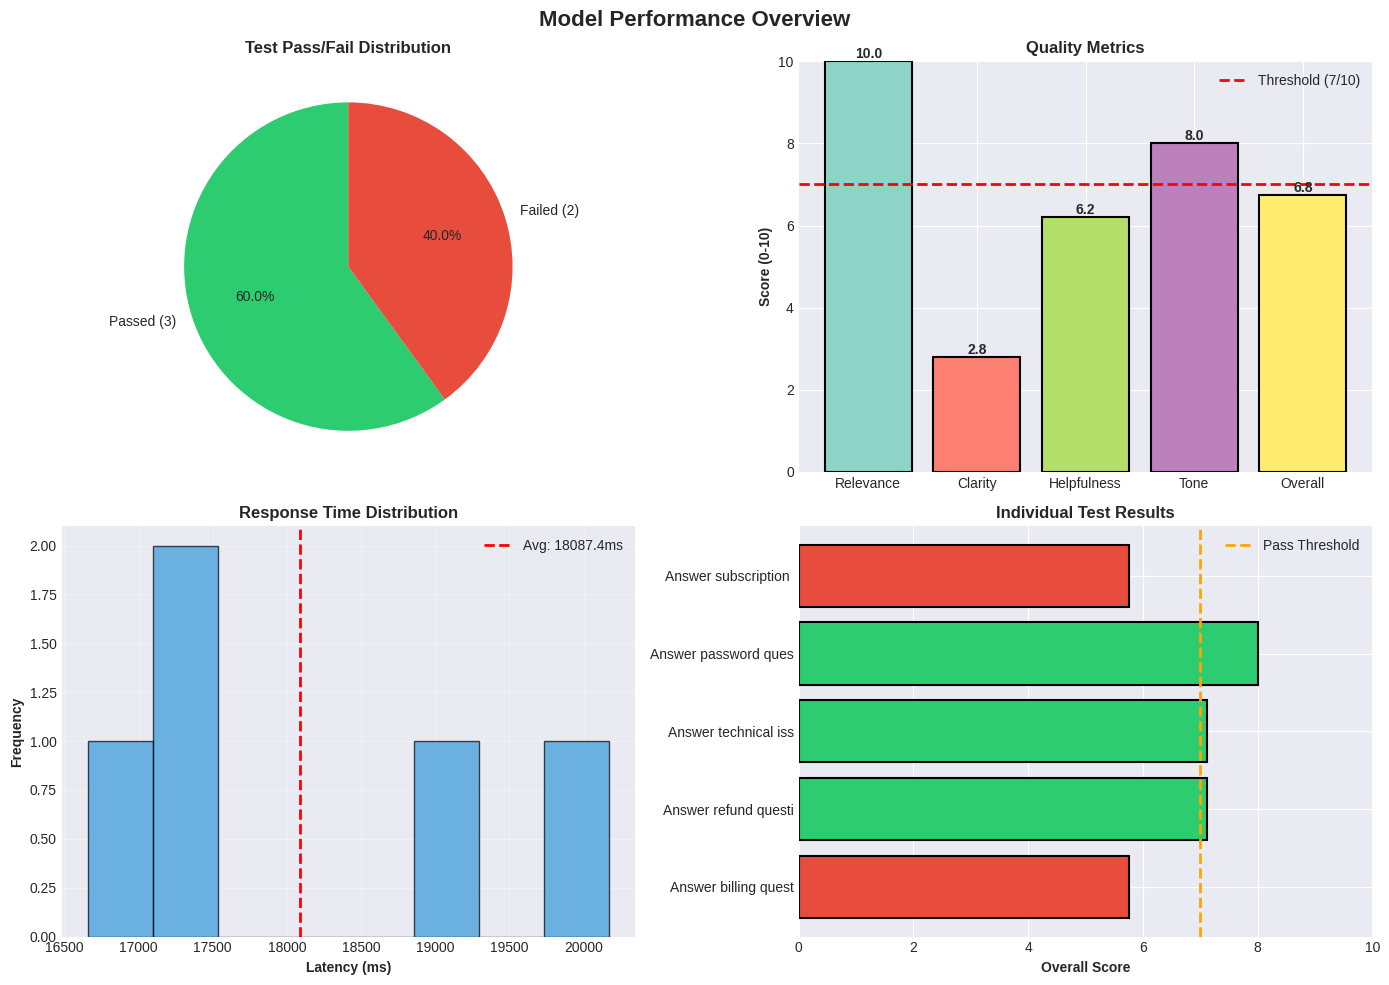

✓ Chart 1: Performance Overview


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Overview', fontsize=16, fontweight='bold')

# 1. Pass/Fail
ax = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
ax.pie([stats['passed'], stats['failed']],
       labels=[f"Passed ({stats['passed']})", f"Failed ({stats['failed']})"],
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Test Pass/Fail Distribution', fontweight='bold')

# 2. Quality Scores
ax = axes[0, 1]
metrics = ['Relevance', 'Clarity', 'Helpfulness', 'Tone', 'Overall']
values = [stats['avg_relevance'], stats['avg_clarity'], stats['avg_helpfulness'],
          stats['avg_tone'], stats['avg_overall']]
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(metrics)))
bars = ax.bar(metrics, values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Score (0-10)', fontweight='bold')
ax.set_title('Quality Metrics', fontweight='bold')
ax.set_ylim([0, 10])
ax.axhline(y=7, color='red', linestyle='--', linewidth=2, label='Threshold (7/10)')
ax.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}',
           ha='center', va='bottom', fontweight='bold')

# 3. Latency Distribution
ax = axes[1, 0]
latencies = [r.latency_ms for r in test_results]
ax.hist(latencies, bins=8, color='#3498db', edgecolor='black', alpha=0.7)
ax.axvline(stats['avg_latency_ms'], color='red', linestyle='--', linewidth=2,
          label=f"Avg: {stats['avg_latency_ms']:.1f}ms")
ax.set_xlabel('Latency (ms)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Response Time Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Test Results
ax = axes[1, 1]
test_names = [r.test_name[:20] for r in test_results]
scores = [r.overall_score for r in test_results]
colors_scatter = ['#2ecc71' if r.passed else '#e74c3c' for r in test_results]
ax.barh(test_names, scores, color=colors_scatter, edgecolor='black', linewidth=1.5)
ax.axvline(x=7, color='orange', linestyle='--', linewidth=2, label='Pass Threshold')
ax.set_xlabel('Overall Score', fontweight='bold')
ax.set_title('Individual Test Results', fontweight='bold')
ax.set_xlim([0, 10])
ax.legend()

plt.tight_layout()
plt.savefig('performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart 1: Performance Overview")

## Step 10: Visualization 2 - Detailed Metrics by Test

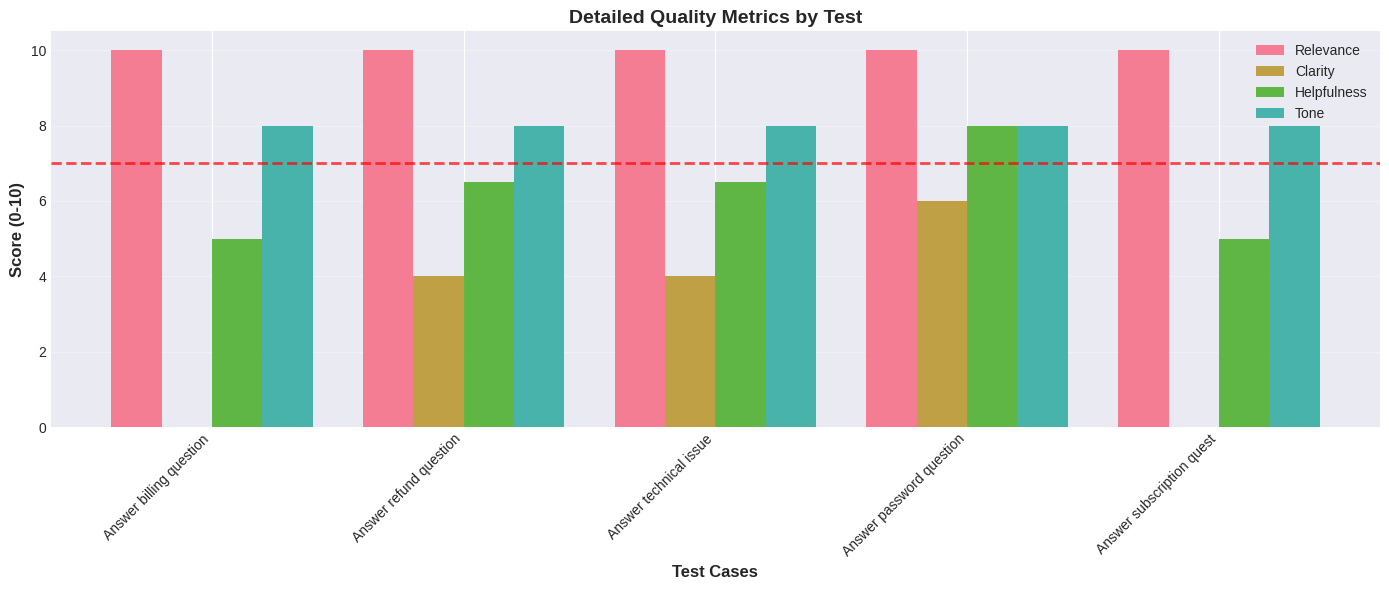

✓ Chart 2: Metrics by Test


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

test_names = [r.test_name[:25] for r in test_results]
x = np.arange(len(test_names))
width = 0.2

ax.bar(x - 1.5*width, [r.relevance for r in test_results], width,
       label='Relevance', alpha=0.9)
ax.bar(x - 0.5*width, [r.clarity for r in test_results], width,
       label='Clarity', alpha=0.9)
ax.bar(x + 0.5*width, [r.helpfulness for r in test_results], width,
       label='Helpfulness', alpha=0.9)
ax.bar(x + 1.5*width, [r.tone for r in test_results], width,
       label='Tone', alpha=0.9)

ax.set_xlabel('Test Cases', fontweight='bold', fontsize=12)
ax.set_ylabel('Score (0-10)', fontweight='bold', fontsize=12)
ax.set_title('Detailed Quality Metrics by Test', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(test_names, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim([0, 10.5])
ax.axhline(y=7, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics_by_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart 2: Metrics by Test")

## Step 11: Visualization 3 - Production Readiness

/tmp/ipykernel_1147/3722602198.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


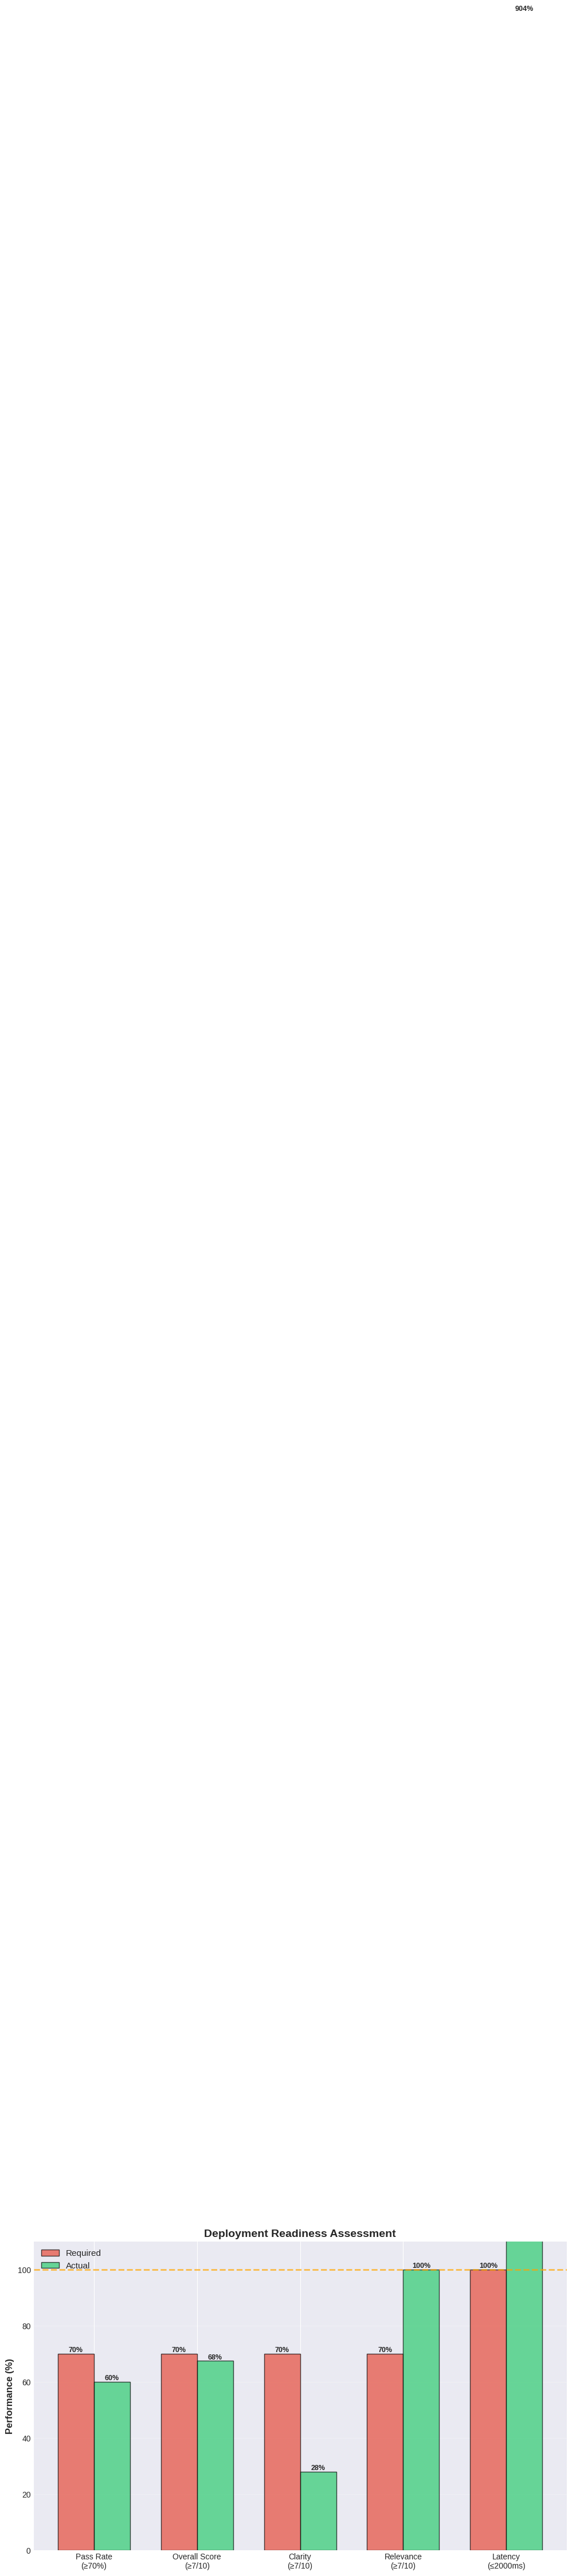

✓ Chart 3: Deployment Readiness


In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

criteria = [
    'Pass Rate\n(≥70%)',
    'Overall Score\n(≥7/10)',
    'Clarity\n(≥7/10)',
    'Relevance\n(≥7/10)',
    'Latency\n(≤2000ms)',
]

target_values = [70, 7, 7, 7, 2000]
actual_values = [
    stats['pass_rate'] * 100,
    stats['avg_overall'],
    stats['avg_clarity'],
    stats['avg_relevance'],
    stats['avg_latency_ms']
]

max_vals = [100, 10, 10, 10, 2000]
normalized_target = [t/m*100 for t, m in zip(target_values, max_vals)]
normalized_actual = [a/m*100 for a, m in zip(actual_values, max_vals)]

x = np.arange(len(criteria))
width = 0.35

bars1 = ax.bar(x - width/2, normalized_target, width, label='Required',
               color='#e74c3c', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, normalized_actual, width, label='Actual',
               color='#2ecc71', alpha=0.7, edgecolor='black')

ax.set_ylabel('Performance (%)', fontweight='bold', fontsize=12)
ax.set_title('Deployment Readiness Assessment', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(criteria)
ax.legend(fontsize=11)
ax.set_ylim([0, 110])
ax.axhline(y=100, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.0f}%',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('deployment_readiness.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart 3: Deployment Readiness")

## Step 12: Visualization 4 - Summary Table

/tmp/ipykernel_1147/432175045.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1147/432175045.py:49: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1147/432175045.py:49: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/cor

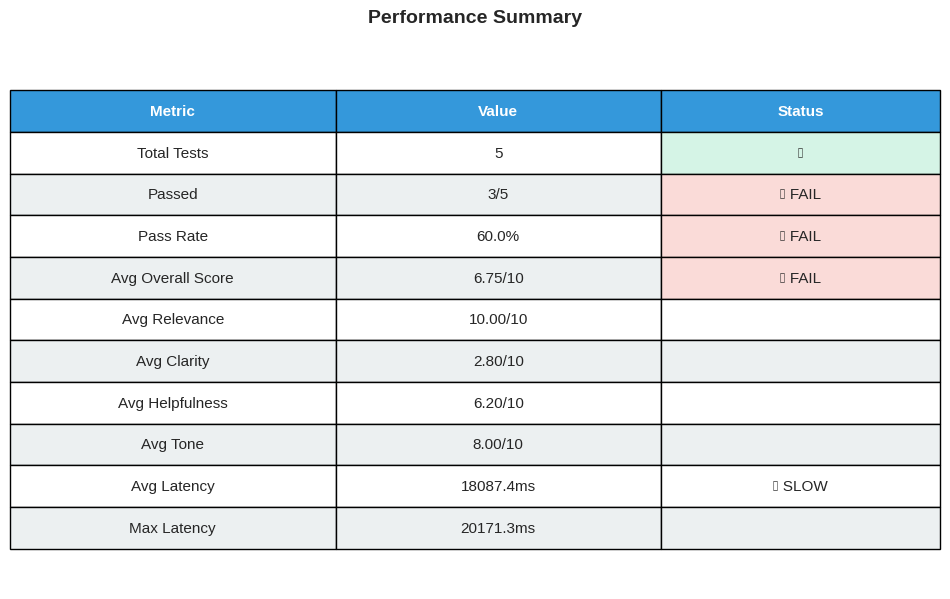

✓ Chart 4: Summary Table


In [14]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

summary_data = [
    ['Metric', 'Value', 'Status'],
    ['Total Tests', f"{stats['total_tests']}", '✓'],
    ['Passed', f"{stats['passed']}/{stats['total_tests']}",
     '✓ PASS' if stats['pass_rate'] >= 0.7 else '✗ FAIL'],
    ['Pass Rate', f"{stats['pass_rate']:.1%}",
     '✓ PASS' if stats['pass_rate'] >= 0.7 else '✗ FAIL'],
    ['Avg Overall Score', f"{stats['avg_overall']:.2f}/10",
     '✓ PASS' if stats['avg_overall'] >= 7 else '✗ FAIL'],
    ['Avg Relevance', f"{stats['avg_relevance']:.2f}/10", ''],
    ['Avg Clarity', f"{stats['avg_clarity']:.2f}/10", ''],
    ['Avg Helpfulness', f"{stats['avg_helpfulness']:.2f}/10", ''],
    ['Avg Tone', f"{stats['avg_tone']:.2f}/10", ''],
    ['Avg Latency', f"{stats['avg_latency_ms']:.1f}ms",
     '✓ PASS' if stats['avg_latency_ms'] <= 2000 else '⚠ SLOW'],
    ['Max Latency', f"{stats['max_latency_ms']:.1f}ms", ''],
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                colWidths=[0.35, 0.35, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style data rows
for i in range(1, len(summary_data)):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

        if j == 2:
            if '✓' in summary_data[i][j]:
                table[(i, j)].set_facecolor('#d5f4e6')
            elif '✗' in summary_data[i][j]:
                table[(i, j)].set_facecolor('#fadbd8')

plt.title('Performance Summary', fontsize=14, fontweight='bold', pad=20)
plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart 4: Summary Table")

## Step 13: Detailed Results Table

In [15]:
# Create DataFrame
df = pd.DataFrame({
    'Test': [r.test_name for r in test_results],
    'Relevance': [f"{r.relevance:.2f}" for r in test_results],
    'Clarity': [f"{r.clarity:.2f}" for r in test_results],
    'Helpfulness': [f"{r.helpfulness:.2f}" for r in test_results],
    'Tone': [f"{r.tone:.2f}" for r in test_results],
    'Overall Score': [f"{r.overall_score:.2f}" for r in test_results],
    'Latency (ms)': [f"{r.latency_ms:.1f}" for r in test_results],
    'Status': ['✓ PASSED' if r.passed else '✗ FAILED' for r in test_results],
})

print("\n" + "="*120)
print("📋 DETAILED TEST RESULTS")
print("="*120)
print(df.to_string(index=False))
print("="*120)


📋 DETAILED TEST RESULTS
                        Test Relevance Clarity Helpfulness Tone Overall Score Latency (ms)   Status
     Answer billing question     10.00    0.00        5.00 8.00          5.75      17138.5 ✗ FAILED
      Answer refund question     10.00    4.00        6.50 8.00          7.12      17527.9 ✓ PASSED
      Answer technical issue     10.00    4.00        6.50 8.00          7.12      18942.4 ✓ PASSED
    Answer password question     10.00    6.00        8.00 8.00          8.00      16656.9 ✓ PASSED
Answer subscription question     10.00    0.00        5.00 8.00          5.75      20171.3 ✗ FAILED


## Step 14: Interactive Visualizations

In [16]:
# Prepare data for interactive charts
df_interactive = pd.DataFrame({
    'Test': [r.test_name for r in test_results],
    'Relevance': [r.relevance for r in test_results],
    'Clarity': [r.clarity for r in test_results],
    'Helpfulness': [r.helpfulness for r in test_results],
    'Tone': [r.tone for r in test_results],
    'Overall Score': [r.overall_score for r in test_results],
    'Latency (ms)': [r.latency_ms for r in test_results],
    'Status': ['✓ PASSED' if r.passed else '✗ FAILED' for r in test_results],
})

# Interactive bar chart
fig1 = px.bar(
    df_interactive,
    x='Test',
    y=['Relevance', 'Clarity', 'Helpfulness', 'Tone'],
    title='Quality Metrics Across All Tests (Interactive)',
    barmode='group',
    labels={'value': 'Score (0-10)', 'variable': 'Metric'},
    height=500
)
fig1.add_hline(y=7, line_dash="dash", line_color="red", annotation_text="Pass Threshold")
fig1.show()

print("✓ Interactive Chart 1: Quality Metrics")

✓ Interactive Chart 1: Quality Metrics


## Step 15: Interactive Scatter Plot

In [17]:
fig2 = px.scatter(
    df_interactive,
    x='Latency (ms)',
    y='Overall Score',
    color='Status',
    size='Overall Score',
    hover_name='Test',
    title='Overall Score vs Latency (Interactive)',
    labels={'Overall Score': 'Overall Score (0-10)'},
    height=500,
    color_discrete_map={'✓ PASSED': '#2ecc71', '✗ FAILED': '#e74c3c'}
)
fig2.add_hline(y=7, line_dash="dash", line_color="orange", annotation_text="Pass Threshold")
fig2.show()

print("✓ Interactive Chart 2: Score vs Latency")

✓ Interactive Chart 2: Score vs Latency


## Step 16: Final Assessment

In [18]:
print("\n" + "="*70)
print("🚀 DEPLOYMENT READINESS ASSESSMENT")
print("="*70)

checks = [
    ("Pass Rate (≥70%)", stats['pass_rate'] >= 0.7, f"{stats['pass_rate']:.1%}"),
    ("Overall Score (≥7/10)", stats['avg_overall'] >= 7, f"{stats['avg_overall']:.2f}"),
    ("Clarity (≥7/10)", stats['avg_clarity'] >= 7, f"{stats['avg_clarity']:.2f}"),
    ("Relevance (≥7/10)", stats['avg_relevance'] >= 7, f"{stats['avg_relevance']:.2f}"),
    ("Latency (≤2000ms)", stats['avg_latency_ms'] <= 2000, f"{stats['avg_latency_ms']:.1f}ms"),
]

for check_name, passed, value in checks:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"{status}: {check_name} - {value}")

ready_for_production = all(check[1] for check in checks)

print("\n" + "="*70)
if ready_for_production:
    print("✅ MODEL IS READY FOR PRODUCTION DEPLOYMENT")
else:
    print("❌ MODEL NEEDS IMPROVEMENTS BEFORE PRODUCTION")
print("="*70)


🚀 DEPLOYMENT READINESS ASSESSMENT
✗ FAIL: Pass Rate (≥70%) - 60.0%
✗ FAIL: Overall Score (≥7/10) - 6.75
✗ FAIL: Clarity (≥7/10) - 2.80
✓ PASS: Relevance (≥7/10) - 10.00
✗ FAIL: Latency (≤2000ms) - 18087.4ms

❌ MODEL NEEDS IMPROVEMENTS BEFORE PRODUCTION
